In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import pycountry

ModuleNotFoundError: No module named 'pycountry'

In [ ]:
# CHARGEMENT DES DONNÉES
df = pd.read_csv('df_final.csv', sep=';')
colonnes_numeriques = df.select_dtypes(include=['float64']).columns.tolist()
df_acp = df[colonnes_numeriques]

In [ ]:
# ACP — ANALYSE EN COMPOSANTES PRINCIPALES

# --- Standardisation ---
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_acp)

# --- ACP ---
pca = PCA()
composantes = pca.fit_transform(df_scaled)
variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)
correlations = pca.components_.T * np.sqrt(pca.explained_variance_)
df_pca = pd.DataFrame(composantes[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_pca['Zone'] = df['Zone'].values
df_pca['Année'] = df['Année'].values
df_pca.head()

,PC1,PC2,PC3,Zone,Année
0,2.407533,-1.100759,-0.806983,Afrique du Sud,2017
1,-0.803059,0.226181,-0.219455,Albanie,2017
2,0.069100,-1.985607,1.038443,Algérie,2017
3,6.425472,5.968792,8.117979,Allemagne,2017
4,-0.679145,-2.094754,1.151606,Angola,2017


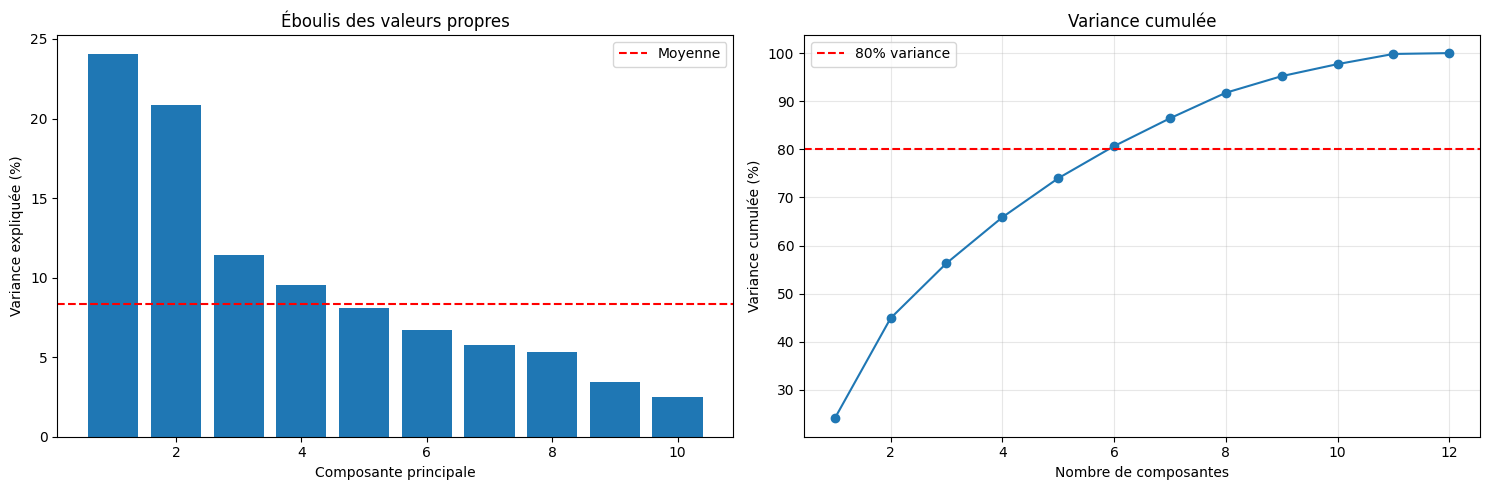

In [ ]:
# --- Éboulis des valeurs propres + Variance cumulée ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, min(11, len(variance_expliquee)+1)), variance_expliquee[:10]*100)
axes[0].axhline(y=100/len(colonnes_numeriques), color='r', linestyle='--', label='Moyenne')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Éboulis des valeurs propres')
axes[0].legend()

axes[1].plot(range(1, len(variance_cumulee)+1), variance_cumulee*100, marker='o')
axes[1].axhline(y=80, color='r', linestyle='--', label='80% variance')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

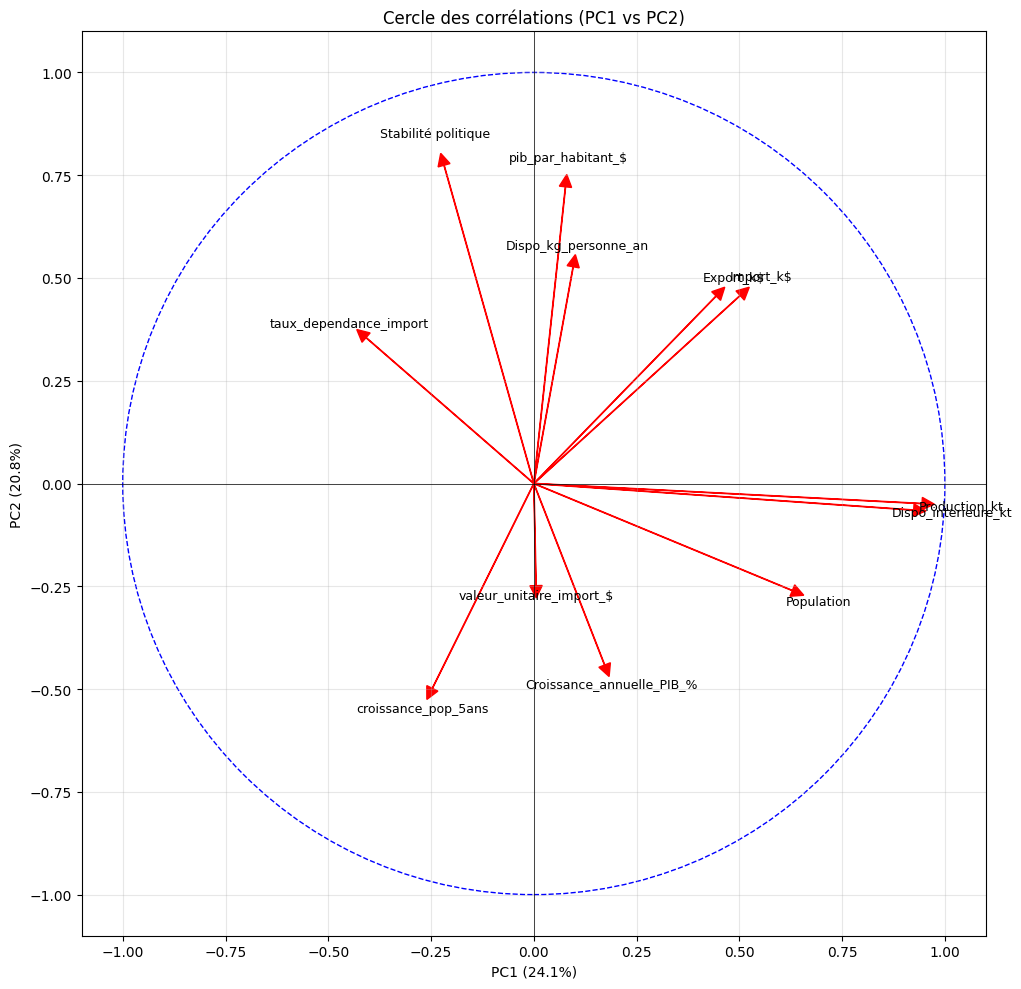

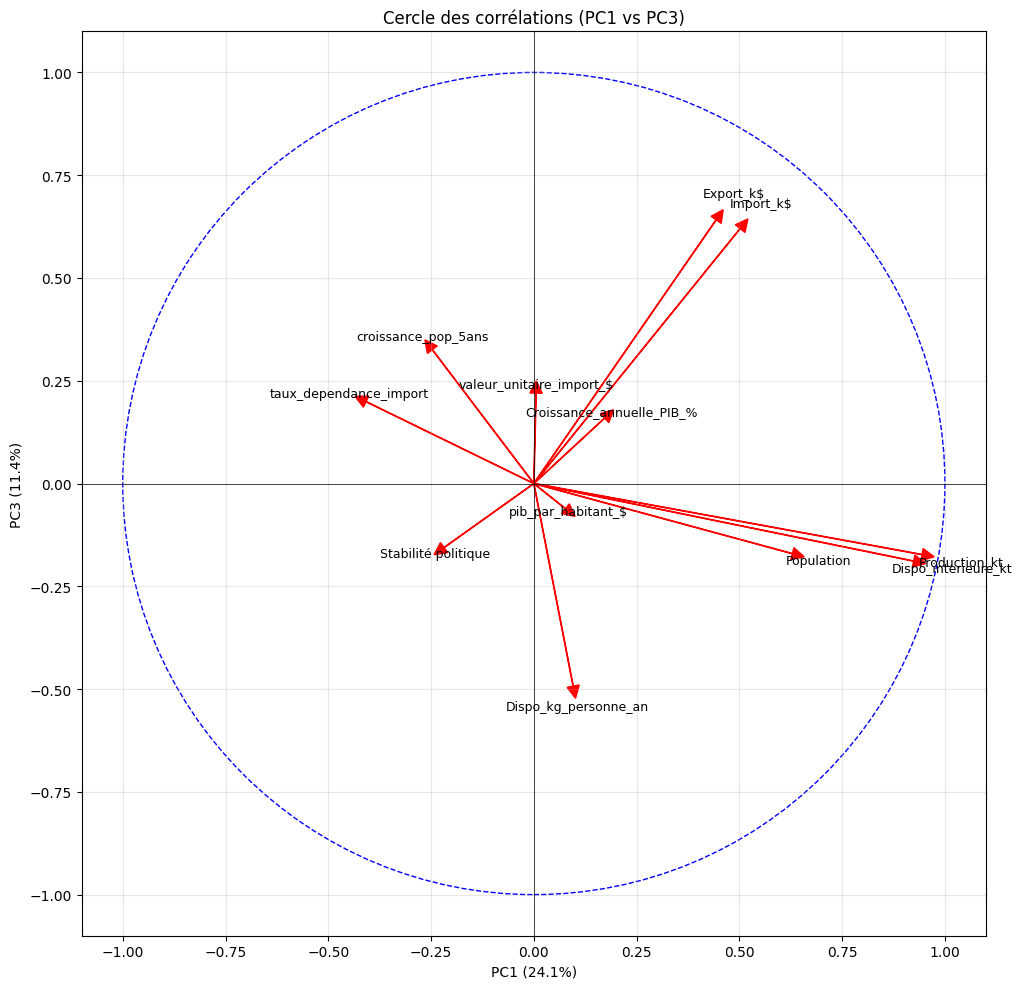

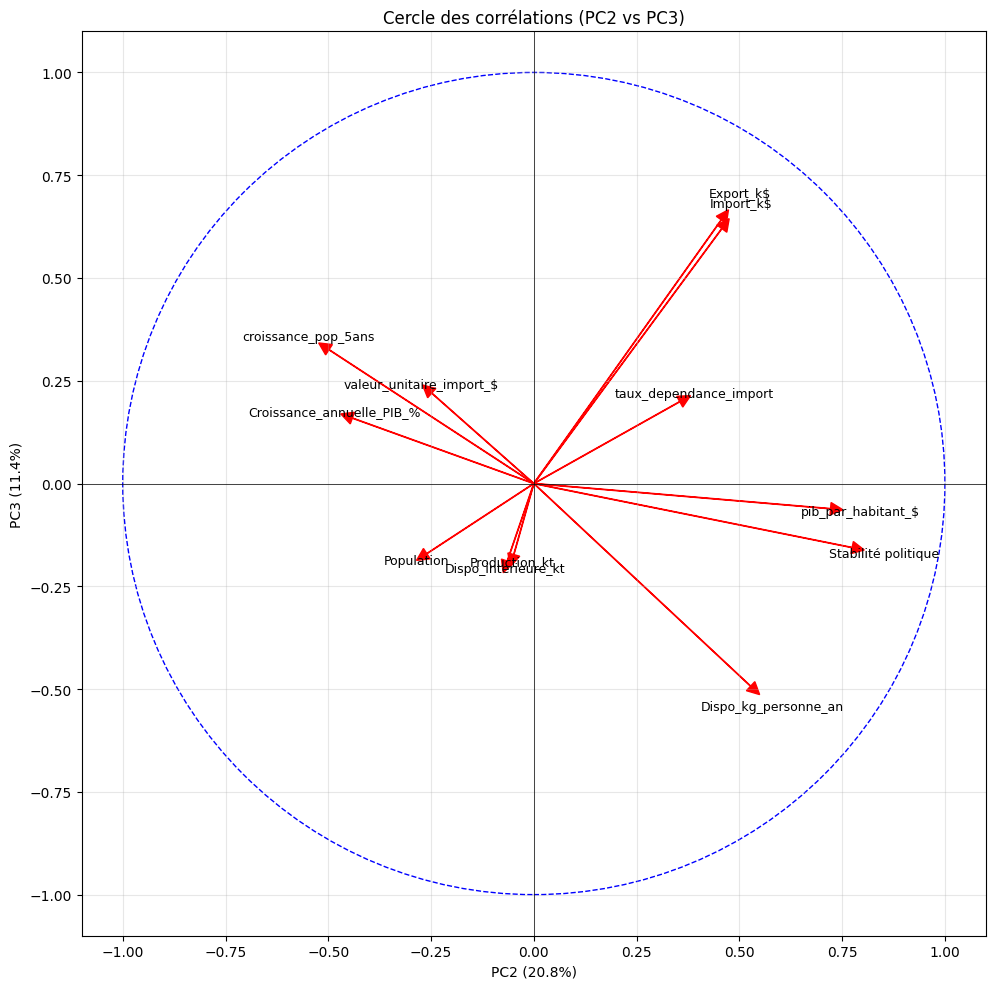

In [ ]:
# --- Cercles des corrélations ---
def cercle_correlations(ax_i, ax_j, titre):
    _, ax = plt.subplots(figsize=(12, 10))
    cercle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
    ax.add_patch(cercle)
    for i, var in enumerate(colonnes_numeriques):
        ax.arrow(0, 0, correlations[i, ax_i], correlations[i, ax_j],
                 head_width=0.03, head_length=0.03, fc='red', ec='red')
        ax.text(correlations[i, ax_i]*1.1, correlations[i, ax_j]*1.1,
                var, fontsize=9, ha='center', va='center')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(f'PC{ax_i+1} ({variance_expliquee[ax_i]*100:.1f}%)')
    ax.set_ylabel(f'PC{ax_j+1} ({variance_expliquee[ax_j]*100:.1f}%)')
    ax.set_title(titre)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

cercle_correlations(0, 1, 'Cercle des corrélations (PC1 vs PC2)')
cercle_correlations(0, 2, 'Cercle des corrélations (PC1 vs PC3)')
cercle_correlations(1, 2, 'Cercle des corrélations (PC2 vs PC3)')

In [ ]:
def projection_individus(pc_x, pc_y, titre):
    fig = px.scatter(
        df_pca,
        x=f'PC{pc_x}',
        y=f'PC{pc_y}',
        hover_name='Zone',
        title=titre,
        labels={
            f'PC{pc_x}': f'PC{pc_x} ({variance_expliquee[pc_x-1]*100:.1f}%)',
            f'PC{pc_y}': f'PC{pc_y} ({variance_expliquee[pc_y-1]*100:.1f}%)'
        }
    )
    fig.update_traces(marker=dict(size=7, color='blue'))
    fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=0.8)
    fig.add_vline(x=0, line_dash='dash', line_color='black', line_width=0.8)
    fig.update_layout(
        width=700,
        height=700,
        yaxis=dict(scaleanchor='x', scaleratio=1)
    )
    fig.show()


projection_individus(1, 2, 'Projection des observations sur PC1 et PC2')
projection_individus(1, 3, 'Projection des observations sur PC1 et PC3')
projection_individus(2, 3, 'Projection des observations sur PC2 et PC3')


CONTRIBUTION DES VARIABLES AUX 3 PREMIÈRES COMPOSANTES
                             PC1    PC2    PC3
Population                 0.369 -0.164 -0.145
croissance_pop_5ans       -0.145 -0.314  0.277
Dispo_kg_personne_an       0.056  0.332 -0.419
Dispo_interieure_kt        0.542 -0.041 -0.161
Import_k$                  0.294  0.288  0.528
Export_k$                  0.260  0.287  0.546
Production_kt              0.554 -0.031 -0.147
valeur_unitaire_import_$   0.003 -0.156  0.187
Croissance_annuelle_PIB_%  0.101 -0.278  0.135
pib_par_habitant_$         0.045  0.455 -0.052
Stabilité politique       -0.128  0.488 -0.133
taux_dependance_import    -0.239  0.224  0.169


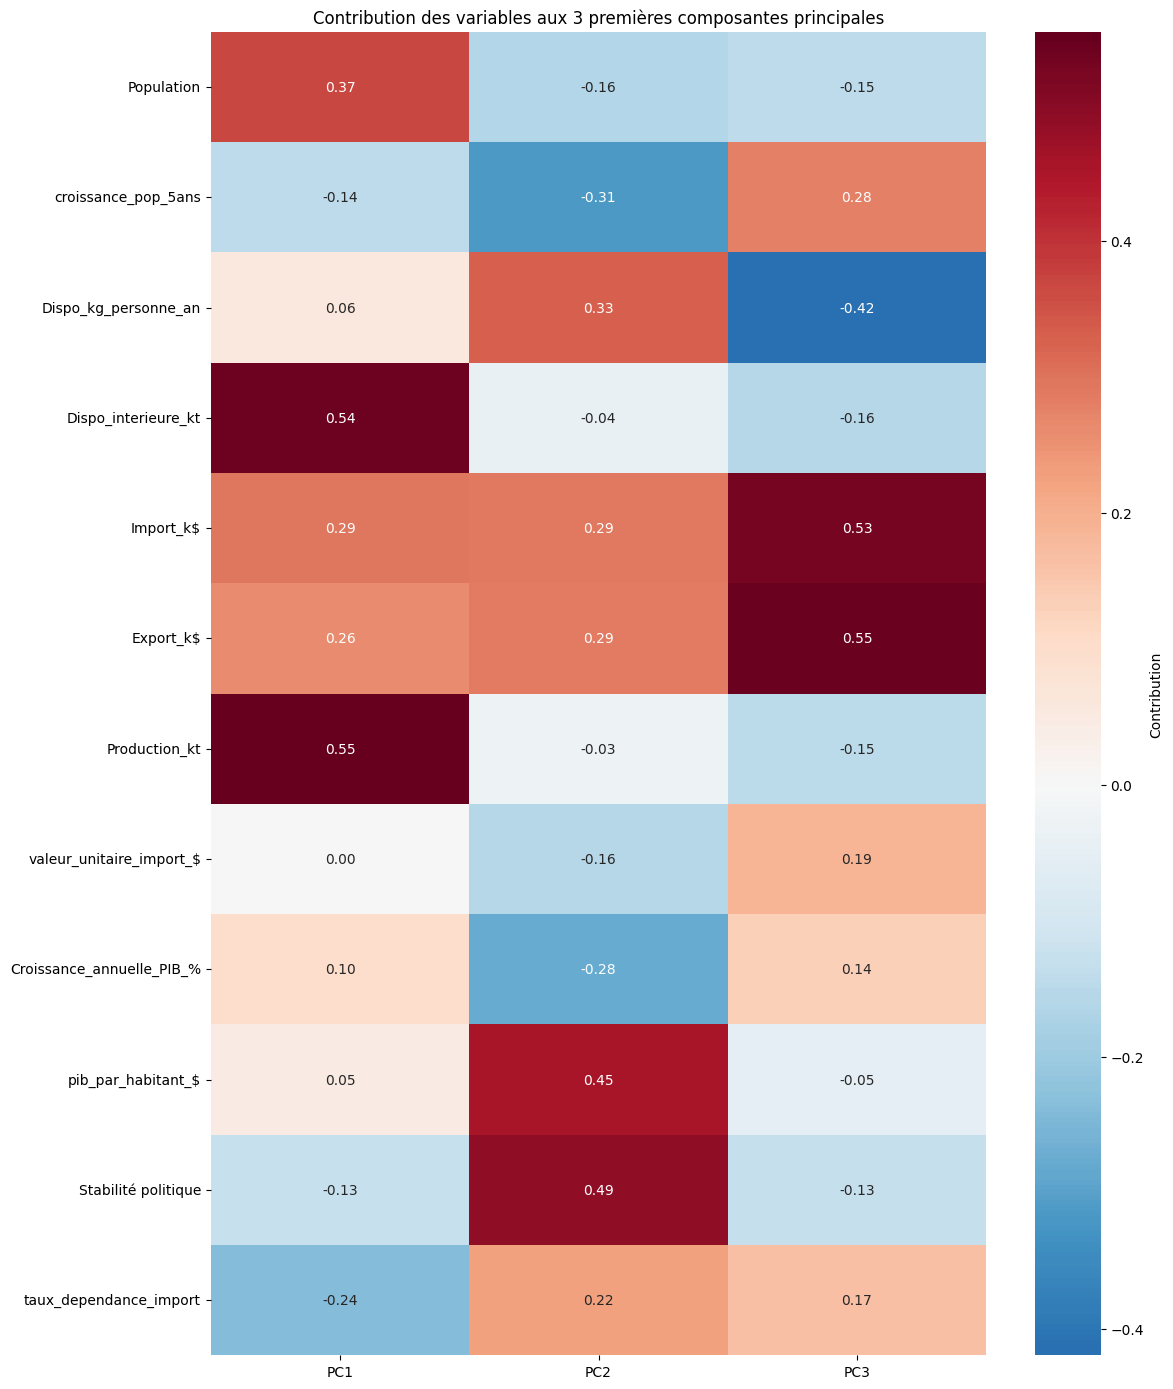

In [ ]:
# --- Contribution des variables (heatmap 3 composantes) ---
contributions = pd.DataFrame(
    pca.components_[:3].T,
    columns=[f'PC{i+1}' for i in range(3)],
    index=colonnes_numeriques
)

print("\n" + "="*80)
print("CONTRIBUTION DES VARIABLES AUX 3 PREMIÈRES COMPOSANTES")
print("="*80)
print(contributions.round(3))

plt.figure(figsize=(12, 14))
sns.heatmap(contributions[['PC1', 'PC2', 'PC3']], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Contribution'})
plt.title('Contribution des variables aux 3 premières composantes principales')
plt.tight_layout()
plt.show()

Interprétation : 
PC1 : Taille et volume du marché
Variables dominantes : Production, Disponibilité intérieure, Population, Import, Export
Oppose les grands pays producteurs et peuplés aux pays à faible volume. 
PC2 : Niveau de développement économique
Variables dominantes : Stabilité politique, PIB par habitant
Variables négatives : Croissance de la population, croissance annuelle du PIB
Oppose les pays riches, stables et à faible croissance (économies matures) aux pays en développement.
PC3 : Intégration dans le commerce international
Variables dominantes : Export, Import
Montre les pays très actifs dans les échanges commerciaux, c'est un axe d'ouverture commerciale.

Pour décider de pays où étendre l'activité :
PC1 -> élevé, grande population = volume important
PC2 -> élevé, PIB/habitant élevé et stabilité politique = marché mature <- axe principal de ciblage
PC3 -> faible/modéré, faible dépendance aux imports = marché à conquérir

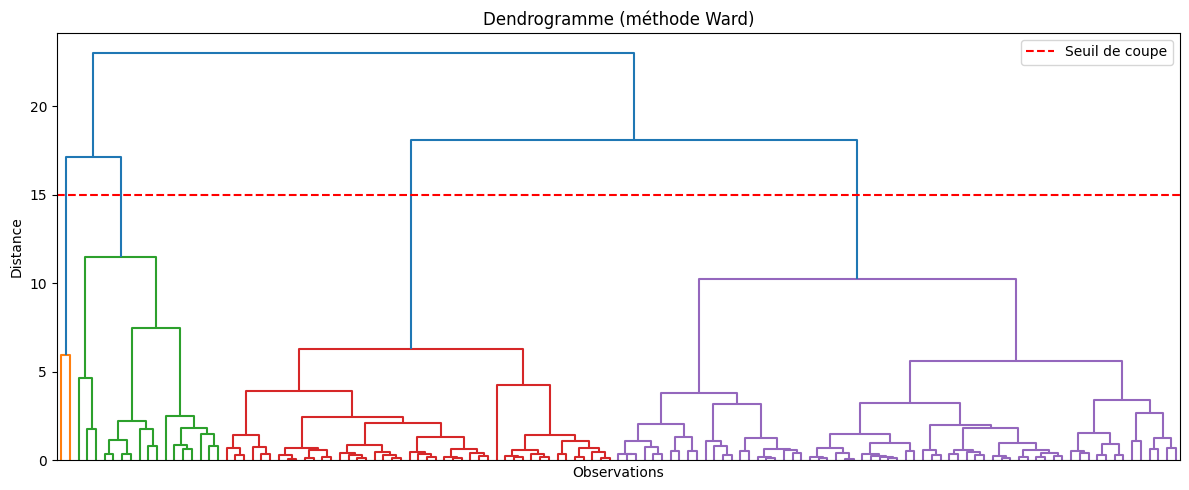

In [ ]:
# ============================================================
# CAH — CLASSIFICATION ASCENDANTE HIÉRARCHIQUE
# ============================================================
X = df_pca[['PC1', 'PC2', 'PC3']]

# --- Dendrogramme ---
Z = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=15)
plt.axhline(y=15, color='red', linestyle='--', label='Seuil de coupe')
plt.title('Dendrogramme (méthode Ward)')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Attribution des clusters CAH ---
df_pca['Cluster_CAH'] = fcluster(Z, t=4, criterion='maxclust')

# --- Projection des individus colorés par Cluster_CAH ---
df_pca['Cluster_CAH_str'] = 'Cluster ' + df_pca['Cluster_CAH'].astype(str)

fig = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    color='Cluster_CAH_str',
    hover_name='Zone',
    title='Projection des observations — Clusters CAH',
    labels={
        'PC1': f'PC1 ({variance_expliquee[0]*100:.1f}%)',
        'PC2': f'PC2 ({variance_expliquee[1]*100:.1f}%)',
        'Cluster_CAH_str': 'Cluster CAH'
    },
    opacity=0.6,
    category_orders={'Cluster_CAH_str': [f'Cluster {i}' for i in sorted(df_pca['Cluster_CAH'].unique())]}
)
fig.update_traces(marker=dict(size=7))
fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=0.8)
fig.add_vline(x=0, line_dash='dash', line_color='black', line_width=0.8)
fig.update_layout(
    width=750,
    height=750,
    yaxis=dict(scaleanchor='x', scaleratio=1)
)
fig.show()


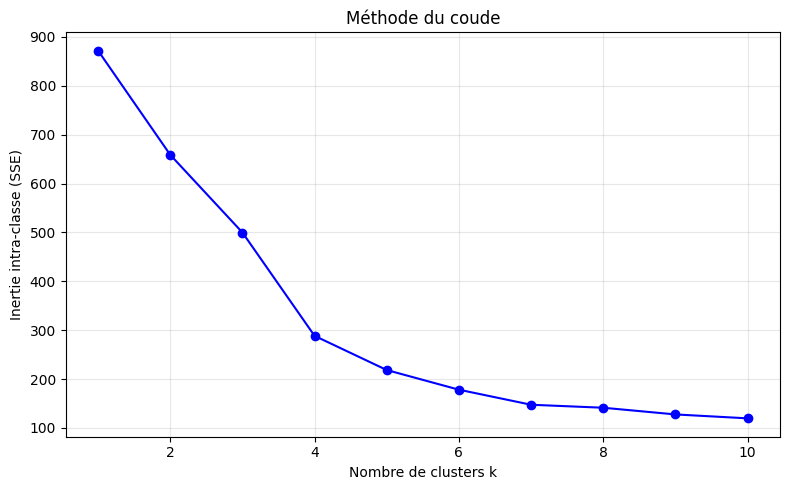

In [ ]:
# ============================================================
# K-MEANS — CHOIX DU K OPTIMAL
# ============================================================

# --- Méthode du coude ---
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-classe (SSE)')
plt.title('Méthode du coude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Meilleur k selon Davies-Bouldin : 4


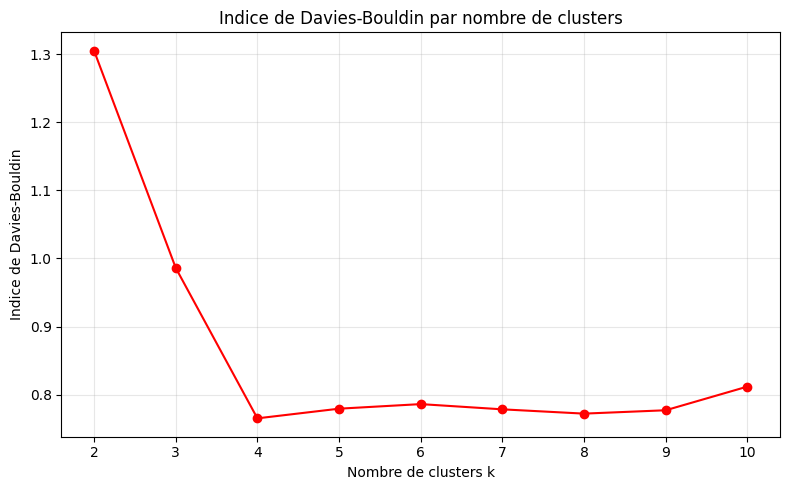

In [ ]:
# --- Indice de Davies-Bouldin ---
db_scores = []
k_values = range(2, 11)

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    db_scores.append(davies_bouldin_score(X, labels))

best_k_db = k_values[db_scores.index(min(db_scores))]
print(f"Meilleur k selon Davies-Bouldin : {best_k_db}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, db_scores, 'ro-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Indice de Davies-Bouldin')
plt.title('Indice de Davies-Bouldin par nombre de clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Meilleur k selon silhouette : 5


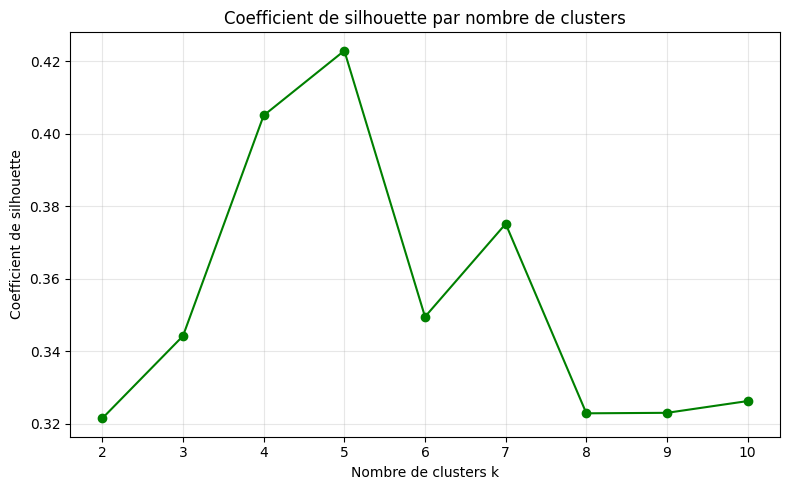

In [ ]:
# --- Coefficient de silhouette ---
silhouette_scores = []

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

best_k_sil = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur k selon silhouette : {best_k_sil}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, 'go-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Coefficient de silhouette')
plt.title('Coefficient de silhouette par nombre de clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# K-MEANS — ANALYSE DES CLUSTERS (k=4 et k=5)
# ============================================================

def analyze_clusters(k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    print(f"\nAnalyse pour k={k} clusters :")
    unique, counts = np.unique(labels, return_counts=True)
    taille_clusters = {int(u): int(c) for u, c in zip(unique, counts)}
    print("Taille des clusters :", taille_clusters)

    print("Centres des clusters :")
    for i, center in enumerate(centers):
        center_rounded = [round(float(coord), 3) for coord in center]
        print(f"  Cluster {i} : {center_rounded}")


    fig = go.Figure()

    for cluster in range(k):
        mask = labels == cluster
        cluster_labels = [f'Cluster {cluster}'] * sum(mask)
        fig.add_trace(go.Scatter3d(
            x=X['PC1'][mask],
            y=X['PC2'][mask],
            z=X['PC3'][mask],
            mode='markers',
            marker=dict(size=5),
            name=f'Cluster {cluster}',
            text=df_pca['Zone'][mask],
            customdata=cluster_labels,
            hovertemplate=(
                '<b>%{text}</b><br>'
                'PC1: %{x:.2f}<br>'
                'PC2: %{y:.2f}<br>'
                'PC3: %{z:.2f}<br>'
                '%{customdata}<extra></extra>'
            )
        ))

    fig.add_trace(go.Scatter3d(
        x=centers[:, 0], y=centers[:, 1], z=centers[:, 2],
        mode='markers',
        marker=dict(size=3, color='black', symbol='x'),
        name='Centres',
        hovertemplate='<b>Centre Cluster %{pointNumber}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
    ))

    fig.update_layout(
        title=f'Clusters K-means (k={k})',
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
        )
    )
    fig.show(config={'scrollZoom': True})

analyze_clusters(4)
analyze_clusters(5)



Analyse pour k=4 clusters :
Taille des clusters : {0: 59, 1: 52, 2: 2, 3: 16}
Centres des clusters :
  Cluster 0 : [-0.652, -1.115, 0.475]
  Cluster 1 : [-0.472, 1.17, -0.59]
  Cluster 2 : [3.982, 5.168, 6.619]
  Cluster 3 : [3.44, -0.335, -0.659]



Analyse pour k=5 clusters :
Taille des clusters : {0: 57, 1: 46, 2: 2, 3: 4, 4: 20}
Centres des clusters :
  Cluster 0 : [-0.711, -1.136, 0.501]
  Cluster 1 : [-0.68, 1.198, -0.626]
  Cluster 2 : [3.982, 5.168, 6.619]
  Cluster 3 : [6.106, -2.104, -1.461]
  Cluster 4 : [1.972, 0.386, -0.359]


In [ ]:
# KMeans avec 5 clusters
kmeans = KMeans(n_clusters=5)
df_pca['Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2', 'PC3']])
df_pca


,PC1,PC2,PC3,Zone,Année,Cluster_CAH,Cluster_CAH_str,Cluster
0,2.407533,-1.100759,-0.806983,Afrique du Sud,2017,2,Cluster 2,2
1,-0.803059,0.226181,-0.219455,Albanie,2017,4,Cluster 4,1
2,0.069100,-1.985607,1.038443,Algérie,2017,3,Cluster 3,0
3,6.425472,5.968792,8.117979,Allemagne,2017,1,Cluster 1,3
4,-0.679145,-2.094754,1.151606,Angola,2017,3,Cluster 3,0
...,...,...,...,...,...,...,...,...
124,1.086055,-0.712755,-0.360809,Viet Nam,2017,4,Cluster 4,2
125,-0.501880,-3.993077,3.255883,Zambie,2017,3,Cluster 3,0
126,-0.489056,-1.659038,0.448150,Zimbabwe,2017,3,Cluster 3,0
127,-0.680823,1.880436,-1.023425,Émirats arabes unis,2017,4,Cluster 4,1


In [ ]:
# Dictionnaire de correspondances français → anglais reconnus par pycountry
corrections = {
    'Afrique du Sud': 'South Africa',
    'Albanie': 'Albania',
    'Algérie': 'Algeria',
    'Allemagne': 'Germany',
    'Antigua-et-Barbuda': 'Antigua and Barbuda',
    'Arabie saoudite': 'Saudi Arabia',
    'Argentine': 'Argentina',
    'Arménie': 'Armenia',
    'Autriche': 'Austria',
    'Azerbaïdjan': 'Azerbaijan',
    'Belgique': 'Belgium',
    'Bolivie (État plurinational de)': 'Bolivia',
    'Bosnie-Herzégovine': 'Bosnia and Herzegovina',
    'Bulgarie': 'Bulgaria',
    'Bélarus': 'Belarus',
    'Bénin': 'Benin',
    'Cambodge': 'Cambodia',
    'Chili': 'Chile',
    'Chine - RAS de Hong-Kong': 'Hong Kong',
    'Chine - RAS de Macao': 'Macao',
    'Chypre': 'Cyprus',
    'Colombie': 'Colombia',
    'Croatie': 'Croatia',
    'Danemark': 'Denmark',
    'Dominique': 'Dominica',
    'Espagne': 'Spain',
    'Estonie': 'Estonia',
    'Fidji': 'Fiji',
    'Finlande': 'Finland',
    'Fédération de Russie': 'RUS',
    'Gambie': 'Gambia',
    'Grenade': 'Grenada',
    'Grèce': 'Greece',
    'Guinée': 'Guinea',
    'Guinée-Bissau': 'Guinea-Bissau',
    'Géorgie': 'Georgia',
    'Haïti': 'Haiti',
    'Hongrie': 'Hungary',
    'Inde': 'India',
    'Indonésie': 'Indonesia',
    "Iran (République islamique d')": 'Iran',
    'Irlande': 'Ireland',
    'Israël': 'Israel',
    'Italie': 'Italy',
    'Jamaïque': 'Jamaica',
    'Japon': 'Japan',
    'Jordanie': 'Jordan',
    'Kirghizistan': 'Kyrgyzstan',
    'Koweït': 'Kuwait',
    'Lettonie': 'Latvia',
    'Libéria': 'Liberia',
    'Lituanie': 'Lithuania',
    'Macédoine du Nord': 'North Macedonia',
    'Malaisie': 'Malaysia',
    'Malte': 'Malta',
    'Maroc': 'Morocco',
    'Maurice': 'Mauritius',
    'Mauritanie': 'Mauritania',
    'Mexique': 'Mexico',
    'Mongolie': 'Mongolia',
    'Monténégro': 'Montenegro',
    'Namibie': 'Namibia',
    'Norvège': 'Norway',
    'Népal': 'Nepal',
    'Ouganda': 'Uganda',
    'Pologne': 'Poland',
    'Pérou': 'Peru',
    'Roumanie': 'Romania',
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": 'United Kingdom',
    'République de Corée': 'South Korea',
    'République de Moldova': 'Moldova',
    'République dominicaine': 'Dominican Republic',
    'République-Unie de Tanzanie': 'Tanzania',
    'Saint-Kitts-et-Nevis': 'Saint Kitts and Nevis',
    'Sainte-Lucie': 'Saint Lucia',
    'Sao Tomé-et-Principe': 'Sao Tome and Principe',
    'Serbie': 'Serbia',
    'Slovaquie': 'Slovakia',
    'Slovénie': 'Slovenia',
    'Suisse': 'Switzerland',
    'Suède': 'Sweden',
    'Sénégal': 'Senegal',
    'Tadjikistan': 'Tajikistan',
    'Tchéquie': 'Czechia',
    'Thaïlande': 'Thailand',
    'Trinité-et-Tobago': 'Trinidad and Tobago',
    'Turkménistan': 'Turkmenistan',
    'Zambie': 'Zambia',
    'Émirats arabes unis': 'United Arab Emirates',
    'Équateur': 'Ecuador'
}

def get_iso3(country_name):
    name = corrections.get(country_name, country_name)
    if len(name) == 3 and name.isupper():
        return name
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

df_pca['iso_alpha'] = df_pca['Zone'].apply(get_iso3)

# Voir les pays qui n'ont pas trouvé de code ISO3
manquants = df_pca[df_pca['iso_alpha'].isna()]['Zone'].unique()
print(f"{len(manquants)} pays sans correspondance :")
print(manquants)

0 pays sans correspondance :
[]


In [ ]:
# ============================================================
# ANALYSE DÉTAILLÉE DES CLUSTERS
# ============================================================

# Ajoute les clusters au dataframe original
df['Cluster'] = df_pca['Cluster'].values

# Calcule les statistiques par cluster sur les variables originales
stats_clusters = df.groupby('Cluster')[colonnes_numeriques].agg(['mean', 'median']).round(2)

# Affichage lisible
for cluster in sorted(df['Cluster'].unique()):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} — {len(df[df['Cluster'] == cluster])} pays")
    print(f"{'='*60}")
    print(f"{'Variable':<35} {'Moyenne':>12} {'Médiane':>12}")
    print(f"{'-'*60}")
    for col in colonnes_numeriques:
        mean = df[df['Cluster'] == cluster][col].mean()
        median = df[df['Cluster'] == cluster][col].median()
        print(f"{col:<35} {mean:>12.2f} {median:>12.2f}")

# Liste des pays par cluster
print(f"\n{'='*60}")
print("PAYS PAR CLUSTER")
print(f"{'='*60}")
for cluster in sorted(df['Cluster'].unique()):
    pays = df[df['Cluster'] == cluster]['Zone'].unique().tolist()
    pays.sort()
    print(f"\nCluster {cluster} ({len(pays)} pays) :")
    print(", ".join(pays))



CLUSTER 0 — 57 pays
Variable                                 Moyenne      Médiane
------------------------------------------------------------
Population                           12095788.60   8880268.00
croissance_pop_5ans                         0.08         0.08
Dispo_kg_personne_an                       11.06         7.93
Dispo_interieure_kt                       113.18        66.00
Import_k$                                3717.84      1853.00
Export_k$                                 369.53         0.00
Production_kt                              88.95        28.00
valeur_unitaire_import_$                   16.60         1.53
Croissance_annuelle_PIB_%                   9.55         7.92
pib_par_habitant_$                       3273.08      2315.63
Stabilité politique                        -0.22        -0.26
taux_dependance_import                      0.51         0.33

CLUSTER 1 — 47 pays
Variable                                 Moyenne      Médiane
-----------------------------

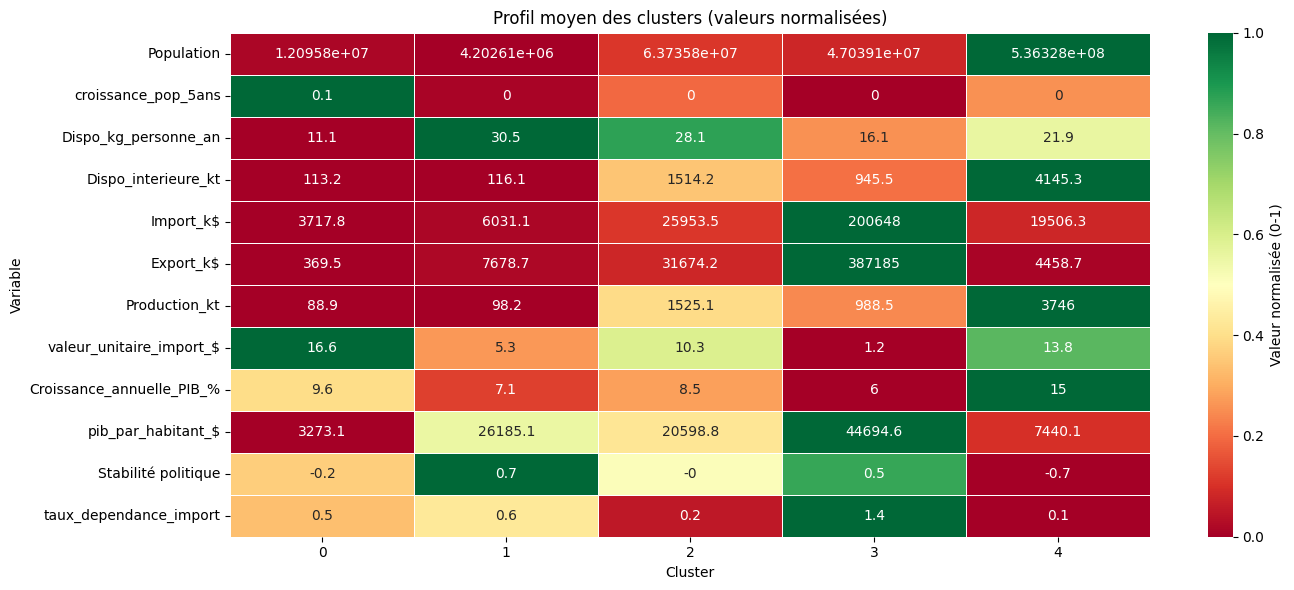

In [ ]:
# Heatmap des profils moyens normalisés par cluster
moyennes = df.groupby('Cluster')[colonnes_numeriques].mean()

# Normalisation pour comparer les variables entre elles
moyennes_norm = (moyennes - moyennes.min()) / (moyennes.max() - moyennes.min())

plt.figure(figsize=(14, 6))
sns.heatmap(
    moyennes_norm.T,
    annot=moyennes.T.round(1),  # affiche les valeurs réelles
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Valeur normalisée (0-1)'}
)
plt.title('Profil moyen des clusters (valeurs normalisées)')
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


Cluster 0 — Pays à forte croissance démographique, marchés émergents -> cible n°4
Population plus grande (~11,8M), PIB/habitant faible (~3,3k$)
Stabilité politique faible/négative (-0.22)
Croissance démographique et PIB élevée (0.08 et 9.45%)
Disponibilité alimentaire faible (~11 kg)
Dépendance import modérée (~0.52)
Exemples : Algérie, Maroc, Sénégal, Cambodge
Nom suggéré : Marchés émergents à forte croissance démographique

Cluster 1 — Pays petits à moyens, marchés stables et développés -> cible n°2
Population modérée (~4,3M), PIB/habitant élevé (~27k$)
Stabilité politique positive (0.74)
Bonne disponibilité alimentaire par personne (~31 kg)
Croissance économique modérée (~7%)
Import/export modérés, dépendance import moyenne (~0.63)
Exemples : Autriche, Danemark, Suisse, Suède, Portugal
Nom suggéré : Marchés développés stables et de taille moyenne

Cluster 2 — Grands marchés matures et diversifiés -> cible n°1
Population élevée (~63M), PIB/habitant moyen (~20k$)
Stabilité politique neutre (~0)
Très forte production et disponibilité intérieure (1500+ kt)
Import/export élevés (25k$+)
Croissance modérée (8.5%)
Exemples : France, Canada, Espagne, Royaume-Uni, Japon
Nom suggéré : Grands marchés matures et intégrés

Cluster 3 — Très grands marchés industriels -> à éviter
Très forte population (~47M), PIB/habitant très élevé (~44k$)
Import/export extrêmement élevés (200k$+)
Forte production industrielle (~988 kt)
Dépendance import très élevée (1.35)
Exemples : Allemagne, Belgique (peut-être des hubs industriels)
Nom suggéré : Hubs industriels majeurs

Cluster 4 — Très grands marchés en développement rapide -> cible n°3
Population énorme (~536M), PIB/habitant faible (~7.4k$)
Croissance économique très élevée (~15%)
Production et disponibilité très élevées (4000+ kt)
Stabilité politique faible/négative (-0.74)
Faible dépendance import (~0.09)
Exemples : Inde, Fédération de Russie, Mexique
Nom suggéré : Grands marchés en forte expansion

comparaison entre cah et kmeans : 2 algos logique différente, ressemblance entre clusters?
KMEANS :
nombre de clusters fixé à l'avance, résultat aléatoire ( clusters de départ choisis aléatoirement ), beaucoup plus rapide si beaucoup de données, adapté pour des clusters "sphériques" 
CAH :
pas besoin de connaitre le nombre de clusters, on le décide en regardant le dendrogramme, toujours le même résultat, moins rapide que kmeans, versatile, désavantage il faut une matrice N*N donc grand cout de calcul et stockage, lent et cher sur des gros jeux de données

différence de prévision normale?

La CAH et le K-Means peuvent donner des résultats différents car leurs logiques sont différentes :
- **CAH** : déterministe (toujours le même résultat), mais sensible aux outliers
- **K-Means** : résultat peut varier selon l'initialisation (d'où `random_state`), plus efficace sur grands jeux de données

Pour choisir, on utilise des métriques objectives : Davies-Bouldin et silhouette.  
 **La méthode avec le meilleur score l'emporte.**

In [ ]:
import plotly.express as px

# Assure-toi que ta colonne 'Cluster' est en string pour une légende qualitative
df_pca['Cluster_str'] = df_pca['Cluster'].astype(str)

fig = px.choropleth(
    df_pca,
    locations='iso_alpha',           # codes ISO 3 lettres
    color='Cluster_str',             # clusters en catégories
    hover_name='Zone',               # nom du pays au survol
    color_discrete_sequence=px.colors.qualitative.Set3,
    title='Carte mondiale des clusters',
    labels={'Cluster_str': 'Cluster'}
)

fig.update_geos(
    projection_type='orthographic',  # projection globe
    showcountries=True,
    showcoastlines=True,
    showland=True,
    landcolor='lightgreen',
    oceancolor='lightblue',
    showocean=True,
    lataxis_showgrid=True,
    lonaxis_showgrid=True
)

fig.update_layout(
    width=800,
    height=600,
    margin={"r":0,"t":40,"l":0,"b":0},
    legend_title_text='Clusters',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='black',
        borderwidth=1
    )
)

fig.show()
